# Step 6: Deployment & Visualization
**FreshGuard ML Pipeline**

The trained model is saved as a `.pkl` file, loaded in the backend, and used to produce both:
- **expiry probability**
- **sell-through-before-expiry probability**

Admin retains full control: accept, modify, or reject suggested actions.


## 6.1 Model Persistence (.pkl)

The model is saved as a binary file and loaded in any Python backend — Flask, FastAPI, Django.

## 6.2 Backend Prediction Function

This backend function loads the model, rebuilds engineered features for a new batch, predicts **expiry probability**, then derives **sell-through-before-expiry probability** for business use.


## 6.3 Full Dashboard Visualization

Deployment environment ready.
Predictions dataset: (100000, 12)
=== Saved Model Files ===
  logistic_regression_model.pkl: 2.6 KB
  random_forest_model.pkl: 223684.6 KB
=== Example Prediction: Milk ===
  expiry_probability: 0.96
  sell_through_before_expiry_probability: 0.04
  risk_level: HIGH
  suggested_discount_pct: 30
  action: Show alert and suggest 30% discount
=== Example Prediction: Biscuits ===
  expiry_probability: 0.36
  sell_through_before_expiry_probability: 0.64
  risk_level: LOW
  suggested_discount_pct: 0
  action: No action needed


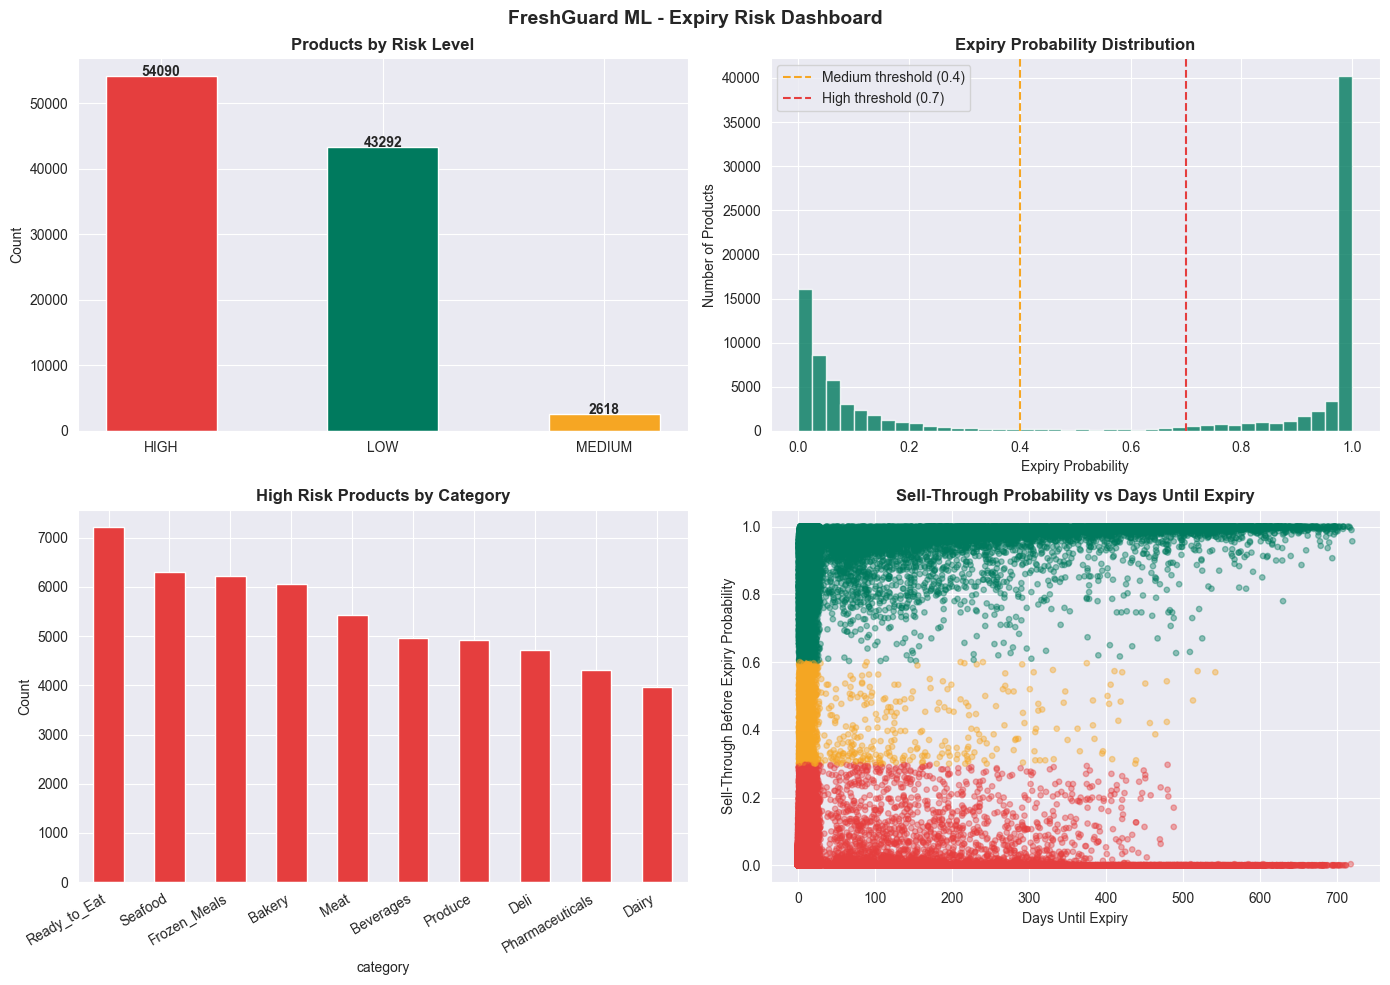

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, json, warnings
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

rf_model = joblib.load('outputs/random_forest_model.pkl')

with open('outputs/feature_list.json') as f:
    meta = json.load(f)
FEATURES = meta['features']
feature_medians = meta.get('feature_medians', {})

with open('outputs/encoding_maps.json') as f:
    encoders = json.load(f)
category_map = encoders.get('category_map', {})
region_map = encoders.get('region_map', {})

default_category_code = next(iter(category_map.values()), 0)
default_region_code = next(iter(region_map.values()), 0)

df_preds = pd.read_csv('outputs/predictions_with_actions.csv')
print('Deployment environment ready.')
print(f'Predictions dataset: {df_preds.shape}')

print('=== Saved Model Files ===')
for fname in ['logistic_regression_model.pkl', 'random_forest_model.pkl']:
    path = f'outputs/{fname}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname}: {size_kb:.1f} KB')

def safe_div(num, den, default=0.0):
    try:
        num = float(num)
        den = float(den)
        if den == 0 or np.isnan(den):
            return float(default)
        value = num / den
        if np.isinf(value) or np.isnan(value):
            return float(default)
        return float(value)
    except Exception:
        return float(default)

def build_feature_row(product_data: dict) -> pd.DataFrame:
    med = {k: float(v) for k, v in feature_medians.items()}
    row = dict(product_data)

    days_until_expiry = float(row.get('days_until_expiry', med.get('days_until_expiry', 0)))
    shelf_life_days = float(row.get('shelf_life_days', med.get('shelf_life_days', 1)))
    storage_temp = float(row.get('storage_temp', med.get('storage_temp', 0)))
    temp_deviation = float(row.get('temp_deviation', med.get('temp_deviation', 0)))
    spoilage_sensitivity = float(row.get('spoilage_sensitivity', med.get('spoilage_sensitivity', 0)))
    daily_demand = float(row.get('daily_demand', row.get('avg_daily_sales', med.get('daily_demand', 0))))
    initial_quantity = float(row.get('initial_quantity', med.get('initial_quantity', 0)))
    units_sold = float(row.get('units_sold', med.get('units_sold', 0)))
    remaining_quantity = row.get('remaining_quantity')
    sell_through_rate = row.get('sell_through_rate')

    if remaining_quantity is None:
        remaining_quantity = max(initial_quantity - units_sold, 0)
    else:
        remaining_quantity = float(remaining_quantity)

    if initial_quantity <= 0 and sell_through_rate is not None and remaining_quantity >= 0:
        sell_through_rate_float = float(sell_through_rate)
        if sell_through_rate_float < 1:
            initial_quantity = remaining_quantity / max(1 - sell_through_rate_float, 1e-6)

    if units_sold <= 0 and sell_through_rate is not None and initial_quantity > 0:
        units_sold = float(sell_through_rate) * initial_quantity

    if sell_through_rate is None:
        sell_through_rate = safe_div(units_sold, initial_quantity, default=med.get('sell_through_rate', 0))
    else:
        sell_through_rate = float(sell_through_rate)

    stock_pressure_ratio = row.get('stock_pressure_ratio')
    if stock_pressure_ratio is None:
        stock_pressure_ratio = safe_div(remaining_quantity, daily_demand, default=med.get('stock_pressure_ratio', 0))
    else:
        stock_pressure_ratio = float(stock_pressure_ratio)

    velocity_score = row.get('velocity_score')
    if velocity_score is None:
        velocity_score = safe_div(daily_demand, shelf_life_days, default=med.get('velocity_score', 0))
    else:
        velocity_score = float(velocity_score)

    sales_volatility = float(row.get('sales_volatility', row.get('demand_variability', med.get('sales_volatility', 0))))

    expiry_pressure_index = row.get('expiry_pressure_index')
    if expiry_pressure_index is None:
        expiry_pressure_index = safe_div(stock_pressure_ratio, days_until_expiry + 1, default=med.get('expiry_pressure_index', 0))
    else:
        expiry_pressure_index = float(expiry_pressure_index)

    price_margin_ratio = row.get('price_margin_ratio')
    if price_margin_ratio is None:
        if 'base_price' in row and 'cost_price' in row:
            price_margin_ratio = safe_div(
                float(row['base_price']) - float(row['cost_price']),
                float(row['base_price']),
                default=med.get('price_margin_ratio', 0)
            )
        else:
            price_margin_ratio = med.get('price_margin_ratio', 0)
    else:
        price_margin_ratio = float(price_margin_ratio)

    category_value = str(row.get('category', ''))
    region_value = str(row.get('region', ''))

    category_encoded = int(row.get('category_encoded', category_map.get(category_value, default_category_code)))
    region_encoded = int(row.get('region_encoded', region_map.get(region_value, default_region_code)))

    feature_row = {
        'days_until_expiry': days_until_expiry,
        'initial_quantity': initial_quantity,
        'shelf_life_days': shelf_life_days,
        'storage_temp': storage_temp,
        'temp_deviation': temp_deviation,
        'spoilage_sensitivity': spoilage_sensitivity,
        'units_sold': units_sold,
        'daily_demand': daily_demand,
        'sell_through_rate': sell_through_rate,
        'remaining_quantity': remaining_quantity,
        'stock_pressure_ratio': stock_pressure_ratio,
        'velocity_score': velocity_score,
        'sales_volatility': sales_volatility,
        'expiry_pressure_index': expiry_pressure_index,
        'price_margin_ratio': price_margin_ratio,
        'category_encoded': category_encoded,
        'region_encoded': region_encoded,
        'is_weekend': int(row.get('is_weekend', med.get('is_weekend', 0))),
        'is_promoted': int(row.get('is_promoted', med.get('is_promoted', 0))),
        'handling_score': float(row.get('handling_score', med.get('handling_score', 0))),
        'packaging_score': float(row.get('packaging_score', med.get('packaging_score', 0))),
        'supplier_score': float(row.get('supplier_score', med.get('supplier_score', 0)))
    }

    feature_df = pd.DataFrame([feature_row])

    for feature in FEATURES:
        if feature not in feature_df.columns:
            feature_df[feature] = med.get(feature, 0)

    return feature_df[FEATURES]

def predict_sell_through_before_expiry(product_data: dict) -> dict:
    feature_df = build_feature_row(product_data)

    expiry_probability = float(rf_model.predict_proba(feature_df)[0][1])
    sell_through_probability = 1 - expiry_probability

    if expiry_probability > 0.70:
        risk_level = 'HIGH'
        suggested_discount_pct = 30
        action = 'Show alert and suggest 30% discount'
    elif expiry_probability >= 0.40:
        risk_level = 'MEDIUM'
        suggested_discount_pct = 15
        action = 'Monitor closely and consider 15% discount'
    else:
        risk_level = 'LOW'
        suggested_discount_pct = 0
        action = 'No action needed'

    return {
        'expiry_probability': round(expiry_probability, 4),
        'sell_through_before_expiry_probability': round(sell_through_probability, 4),
        'risk_level': risk_level,
        'suggested_discount_pct': suggested_discount_pct,
        'action': action
    }

# Example 1: Milk
milk_batch = {
    'product_name': 'Milk (Batch #M-7842)',
    'category': 'Dairy',
    'region': 'Region_1',
    'days_until_expiry': 12,
    'initial_quantity': 1675,
    'units_sold': 1430,
    'remaining_quantity': 245,
    'daily_demand': 38.2,
    'shelf_life_days': 14,
    'storage_temp': 4.0,
    'temp_deviation': 0.5,
    'spoilage_sensitivity': 0.85,
    'demand_variability': 0.22,
    'is_weekend': 0,
    'is_promoted': 0,
    'handling_score': 8,
    'packaging_score': 8,
    'supplier_score': 8,
    'base_price': 450,
    'cost_price': 320
}

# Example 2: Biscuits
biscuit_batch = {
    'product_name': 'Biscuits (Batch #B-3921)',
    'category': 'Bakery',
    'region': 'Region_1',
    'days_until_expiry': 68,
    'initial_quantity': 1892,
    'units_sold': 1850,
    'remaining_quantity': 42,
    'daily_demand': 28.4,
    'shelf_life_days': 90,
    'storage_temp': 24.0,
    'temp_deviation': 1.0,
    'spoilage_sensitivity': 0.20,
    'demand_variability': 0.15,
    'is_weekend': 0,
    'is_promoted': 0,
    'handling_score': 9,
    'packaging_score': 9,
    'supplier_score': 8,
    'base_price': 180,
    'cost_price': 110
}

print('=== Example Prediction: Milk ===')
for key, value in predict_sell_through_before_expiry(milk_batch).items():
    print(f'  {key}: {value}')

print('=== Example Prediction: Biscuits ===')
for key, value in predict_sell_through_before_expiry(biscuit_batch).items():
    print(f'  {key}: {value}')

# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FreshGuard ML - Expiry Risk Dashboard', fontweight='bold', fontsize=14)

risk_counts = df_preds['risk_level'].value_counts()
color_map = {'HIGH': '#E53E3E', 'MEDIUM': '#F6A623', 'LOW': '#007A5E'}
axes[0, 0].bar(
    risk_counts.index,
    risk_counts.values,
    color=[color_map[level] for level in risk_counts.index],
    edgecolor='white',
    width=0.5
)
axes[0, 0].set_title('Products by Risk Level', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, value in enumerate(risk_counts.values):
    axes[0, 0].text(i, value + 2, str(value), ha='center', fontweight='bold')

axes[0, 1].hist(
    df_preds['expiry_probability'],
    bins=40,
    color='#007A5E',
    edgecolor='white',
    alpha=0.8
)
axes[0, 1].axvline(0.4, color='#F6A623', linestyle='--', label='Medium threshold (0.4)')
axes[0, 1].axvline(0.7, color='#E53E3E', linestyle='--', label='High threshold (0.7)')
axes[0, 1].set_title('Expiry Probability Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Expiry Probability')
axes[0, 1].set_ylabel('Number of Products')
axes[0, 1].legend()

high_risk = df_preds[df_preds['risk_level'] == 'HIGH']
cat_high = high_risk.groupby('category').size().sort_values(ascending=False)
if len(cat_high) > 0:
    cat_high.plot(kind='bar', ax=axes[1, 0], color='#E53E3E', edgecolor='white')
axes[1, 0].set_title('High Risk Products by Category', fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xticklabels(cat_high.index, rotation=30, ha='right')

scatter_colors = df_preds['risk_level'].map(color_map)
axes[1, 1].scatter(
    df_preds['days_until_expiry'],
    df_preds['sell_through_before_expiry_probability'],
    c=scatter_colors,
    alpha=0.4,
    s=15
)
axes[1, 1].set_title('Sell-Through Probability vs Days Until Expiry', fontweight='bold')
axes[1, 1].set_xlabel('Days Until Expiry')
axes[1, 1].set_ylabel('Sell-Through Before Expiry Probability')

plt.tight_layout()
plt.savefig('outputs/dashboard.png', dpi=120, bbox_inches='tight')
plt.show()


## 6.4 System Flow

```
Inventory DB + Sales DB
        |
        v
Feature Engineering
        |
        v
RF Model (.pkl) -> expiry_probability
        |
        v
Derived metric: 1 - expiry_probability
        |
        v
sell_through_before_expiry_probability
        |
        v
Business Rule Layer
[ >0.7 expiry risk = ALERT ]
[ 0.4-0.7 = WARNING ]
[ <0.4 = OK ]
```


In [2]:
summary = df_preds['risk_level'].value_counts().to_dict()
print('=== Final Pipeline Summary ===')
print(f'Total products analyzed: {len(df_preds)}')
print(f'HIGH risk:   {summary.get("HIGH", 0)} products -> suggest immediate discount')
print(f'MEDIUM risk: {summary.get("MEDIUM", 0)} products -> monitor closely')
print(f'LOW risk:    {summary.get("LOW", 0)} products -> no action needed')
print()
print('Output artifacts:')
for fname in sorted(os.listdir('outputs')):
    size_kb = os.path.getsize(f'outputs/{fname}') / 1024
    print(f'  outputs/{fname} ({size_kb:.1f} KB)')


=== Final Pipeline Summary ===
Total products analyzed: 100000
HIGH risk:   54090 products -> suggest immediate discount
MEDIUM risk: 2618 products -> monitor closely
LOW risk:    43292 products -> no action needed

Output artifacts:
  outputs/X_test.csv (2011.2 KB)
  outputs/X_train.csv (8045.7 KB)
  outputs/cleaned_dataset.csv (35554.5 KB)
  outputs/confusion_matrices.png (42.1 KB)
  outputs/dashboard.png (333.2 KB)
  outputs/encoding_maps.json (0.3 KB)
  outputs/feature_correlation.png (62.2 KB)
  outputs/feature_dataset.csv (11528.7 KB)
  outputs/feature_importance.png (47.1 KB)
  outputs/feature_list.json (1.3 KB)
  outputs/logistic_regression_model.pkl (2.6 KB)
  outputs/ml_api_jupyter.log (3.2 KB)
  outputs/ml_api_manual.err.log (0.0 KB)
  outputs/ml_api_manual.out.log (0.0 KB)
  outputs/model_comparison.csv (0.2 KB)
  outputs/predictions_with_actions.csv (9915.5 KB)
  outputs/probability_distributions.png (49.2 KB)
  outputs/random_forest_model.pkl (223684.6 KB)
  outputs/risk_

## Deployment Summary

| Artifact | File | Purpose |
|---|---|---|
| Primary model | `random_forest_model.pkl` | Load and predict expiry risk |
| Baseline model | `logistic_regression_model.pkl` | Comparison |
| Predictions | `predictions_with_actions.csv` | Dashboard and action layer |
| Feature metadata | `feature_list.json` | Stable feature order + medians |
| Encoding maps | `encoding_maps.json` | Stable category and region encoding |

The deployment layer now reports both technical and business probabilities consistently.


## 6.5 Run the ML API from Jupyter

Run the next cells when you want the Spring Boot backend to call the trained Random Forest model. This replaces opening a terminal and typing `cd AIML`, `pip install -r requirements.txt`, and `uvicorn main:app --reload --port 8000`.

The API stays alive while this notebook kernel is running. If you update package versions, restart the kernel once and run these cells again.


In [3]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

cwd = Path.cwd().resolve()
if (cwd / 'main.py').exists() and (cwd / 'outputs').exists():
    AIML_DIR = cwd
elif (cwd / 'AIML' / 'main.py').exists() and (cwd / 'AIML' / 'outputs').exists():
    AIML_DIR = cwd / 'AIML'
else:
    raise FileNotFoundError('Open this notebook from the project root or the AIML folder.')

os.chdir(AIML_DIR)
requirements_path = AIML_DIR / 'requirements.txt'
print(f'AIML folder: {AIML_DIR}')
print(f'Requirements: {requirements_path}')

required_modules = {
    'fastapi': 'fastapi',
    'uvicorn': 'uvicorn',
    'pandas': 'pandas',
    'joblib': 'joblib',
    'sklearn': 'scikit-learn',
}
missing_packages = [package for module, package in required_modules.items() if importlib.util.find_spec(module) is None]

try:
    import sklearn
    sklearn_version = sklearn.__version__
except Exception:
    sklearn_version = None

needs_sklearn_pin = sklearn_version != '1.8.0'
if missing_packages or needs_sklearn_pin:
    print('Installing/updating ML API dependencies in this Jupyter environment...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)])
    print('Dependencies installed. If scikit-learn changed, restart the kernel once, then rerun this cell and the API start cell.')
else:
    print('Dependencies already look ready.')


AIML folder: C:\Users\ASUS\Downloads\invigo-freshguard-main Final (1)\invigo-freshguard-main Final\invigo-freshguard-main\AIML
Requirements: C:\Users\ASUS\Downloads\invigo-freshguard-main Final (1)\invigo-freshguard-main Final\invigo-freshguard-main\AIML\requirements.txt
Dependencies already look ready.


In [4]:
import json
import os
import subprocess
import sys
import time
import urllib.error
import urllib.request
from pathlib import Path

API_HOST = '127.0.0.1'
API_PORT = 8000
API_BASE_URL = f'http://{API_HOST}:{API_PORT}'
health_url = f'{API_BASE_URL}/health'


def api_is_running(url=health_url):
    try:
        with urllib.request.urlopen(url, timeout=2) as response:
            return response.status == 200
    except Exception:
        return False


if api_is_running():
    print(f'ML API is already running: {API_BASE_URL}')
else:
    log_path = Path('outputs') / 'ml_api_jupyter.log'
    log_path.parent.mkdir(parents=True, exist_ok=True)
    ML_API_LOG_FILE = open(log_path, 'a', encoding='utf-8')
    ML_API_PROCESS = subprocess.Popen(
        [sys.executable, '-m', 'uvicorn', 'main:app', '--host', API_HOST, '--port', str(API_PORT)],
        cwd=str(AIML_DIR),
        stdout=ML_API_LOG_FILE,
        stderr=subprocess.STDOUT,
        env={**os.environ, 'PYTHONUNBUFFERED': '1'},
    )

    for _ in range(20):
        if api_is_running():
            break
        time.sleep(1)

    if api_is_running():
        print(f'ML API started: {API_BASE_URL}')
        print(f'Health check: {health_url}')
        print(f'Log file: {log_path.resolve()}')
    else:
        print('ML API did not start within 20 seconds.')
        print(f'Check the log file: {log_path.resolve()}')


ML API started: http://127.0.0.1:8000
Health check: http://127.0.0.1:8000/health
Log file: C:\Users\ASUS\Downloads\invigo-freshguard-main Final (1)\invigo-freshguard-main Final\invigo-freshguard-main\AIML\outputs\ml_api_jupyter.log


In [5]:
import json
import urllib.request

sample_payload = {
    'days_until_expiry': 3,
    'initial_quantity': 40,
    'shelf_life_days': 10,
    'storage_temp': 4,
    'temp_deviation': 1.4,
    'spoilage_sensitivity': 0.75,
    'units_sold': 10,
    'daily_demand': 3,
    'sell_through_rate': 0.25,
    'remaining_quantity': 30,
    'stock_pressure_ratio': 10,
    'velocity_score': 0.3,
    'sales_volatility': 0.3,
    'expiry_pressure_index': 2.5,
    'price_margin_ratio': 0.45,
    'category_encoded': 2,
    'region_encoded': 2,
    'is_weekend': 0,
    'is_promoted': 0,
    'handling_score': 7,
    'packaging_score': 7,
    'supplier_score': 9,
}

request = urllib.request.Request(
    f'{API_BASE_URL}/predict',
    data=json.dumps(sample_payload).encode('utf-8'),
    headers={'Content-Type': 'application/json'},
    method='POST',
)
with urllib.request.urlopen(request, timeout=10) as response:
    result = json.loads(response.read().decode('utf-8'))

print(json.dumps(result, indent=2))


{
  "expiry_risk_probability": 1.0,
  "predicted_label": 1,
  "risk_label": "High Risk",
  "suggested_action": "Show alert and suggest 30% discount",
  "decision_threshold": 0.4,
  "prediction_source": "AIML_RANDOM_FOREST"
}


In [10]:
# Optional: run this cell only when you want to stop the ML API started by this notebook.
try:
    ML_API_PROCESS.terminate()
    ML_API_PROCESS.wait(timeout=10)
    print('ML API stopped.')
except NameError:
    print('No ML_API_PROCESS found in this kernel. The API may have been started elsewhere.')
except Exception as exc:
    print(f'Could not stop cleanly: {exc}')
finally:
    try:
        ML_API_LOG_FILE.close()
    except Exception:
        pass


ML API stopped.
